 ## COUPLED MAP LATTICE (CML) EXPLORATION

 Local map: x_{n+1} = x_n^2 * exp(r - x_n)
 Parameter: r ∈ [1, 3]

 This script explores the dynamics of coupled map lattices where each node
 follows the Ricker-like map x_{n+1} = x_n^2 * exp(r - x_n).

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.animation import FuncAnimation
import warnings
warnings.filterwarnings("default")

In [19]:
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# setting up the style and color schemes

plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor':   '#0d0d1a',
    'axes.edgecolor':   '#333355',
    'axes.labelcolor':  '#ccccee',
    'xtick.color':      '#999999',
    'ytick.color':      '#999999',
    'text.color':       '#eeeeee',
    'grid.color':       '#1a1a33',
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
})

PLASMA_DARK = LinearSegmentedColormap.from_list(
    'plasma_dark', ['#0d0d1a', '#6a0572', '#d63384', '#ff8c00', '#ffff66'])
CYAN_FIRE = LinearSegmentedColormap.from_list(
    'cyan_fire', ['#001122', '#003366', '#00aaff', '#ff6600', '#ffee00'])

In [3]:
# Local Map Dynamics

def local_map(x, r):
    """
    Map: x_{n+1} = x_n^2 * exp(r - x_n)

    x : float or ndarray  - current state (must be > 0)
    r : float             - growth parameter in [1, 3]
    Returns the next state, clipped to avoid blow-up.
    """
    x = np.clip(x, 1e-10, 500)          # keep x positive and bounded
    x_new = x**2 * np.exp(r - x)
    return np.clip(x_new, 1e-10, 500)  

In [ ]:
# Bifurcation Diagram (Single uncoupled node)

def plot_bifurcation():
    """
    Sweep r from 1 to 3 and plot the long-run orbit (after transients).
    This reveals fixed points, period-doubling, and chaos.
    """
    r_values   = np.linspace(1.0, 3.0, 2000)   # 2000 values of r
    transient  = 500    
    n_plot     = 200    # iterations to keep for the diagram

    # Store r and x values for plotting
    r_plot, x_plot = [], []

    for r in r_values:
        x = 1.5   # initial condition
        
        for _ in range(transient):
            x = local_map(x, r)
       
        for _ in range(n_plot):
            x = local_map(x, r)
            r_plot.append(r)
            x_plot.append(x)

    fig, ax = plt.subplots(figsize=(14, 7), facecolor='#0d0d1a')
    ax.set_facecolor('#0d0d1a')

    # Colour points by density using a 2D histogram colour trick
    ax.scatter(r_plot, x_plot, s=0.3, c=x_plot, cmap='plasma', alpha=0.5,
               linewidths=0, rasterized=True)

    ax.set_xlabel('Parameter  r', fontsize=13)
    ax.set_ylabel('Attractor value  x*', fontsize=13)
    ax.set_title('BIFURCATION DIAGRAM\n'
                 r'$x_{n+1} = x_n^2\,e^{r-x_n}$',
                 fontsize=16, pad=15, color='#ff9966')
    ax.grid(True, alpha=0.2)

    # Annotate key transitions
    for rx, label, col in [(1.5, 'Fixed\npoint', '#00ffcc'),
                           (2.2, 'Period\ndoubling', '#ffaa00'),
                           (2.7, 'Chaos', '#ff4444')]:
        ax.axvline(rx, color=col, lw=0.8, linestyle='--', alpha=0.6)
        ax.text(rx+0.01, ax.get_ylim()[1]*0.85, label,
                color=col, fontsize=9, va='top')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig1_bifurcation.png"), bbox_inches="tight", facecolor='#0d0d1a')
    plt.close()


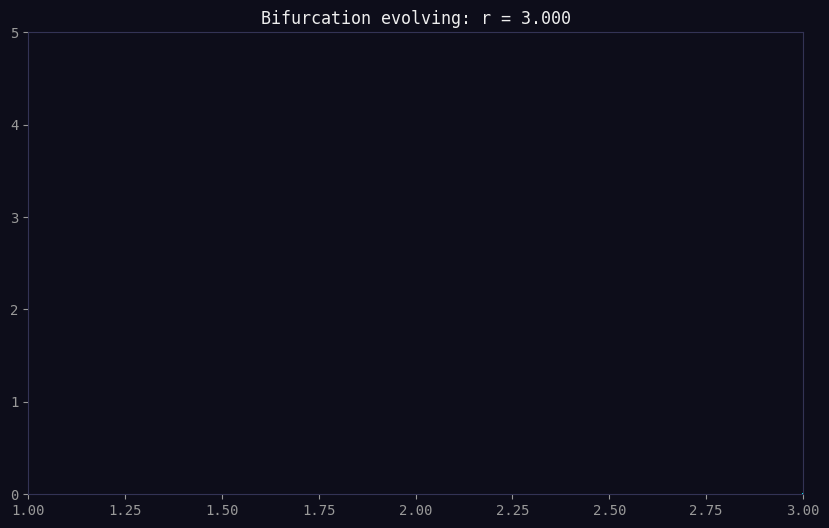

In [ ]:
# Animation of bifurcation diagram evolving with r

def animate_bifurcation():
    fig, ax = plt.subplots(figsize=(10,6))
    ax.set_xlim(1, 3)
    ax.set_ylim(0, 5)

    scat = ax.scatter([], [], s=1, c='cyan')

    r_values = np.linspace(1.0, 3.0, 300)

    def update(frame):
        r = r_values[frame]
        x = 1.5

        # transient
        for _ in range(300):
            x = local_map(x, r)

        xs = []
        rs = []
        for _ in range(100):
            x = local_map(x, r)
            xs.append(x)
            rs.append(r)

        scat.set_offsets(np.c_[rs, xs])
        ax.set_title(f"Bifurcation evolving: r = {r:.3f}")
        return scat,

    anim = FuncAnimation(fig, update, frames=len(r_values), interval=30)
    anim.save("outputs/bifurcation_animation.mp4", fps=30)

animate_bifurcation()   ## Refer to the uploaded file to see the animation of the bifurcation diagram evolving with r

In [ ]:
# TIME SERIES  for several r values

def plot_time_series():
    """
    Show how the time series looks for different values of r:
    stable, periodic, and chaotic regimes.
    """

    r_cases = [1.4, 2.0, 2.5, 2.9]
    labels  = ['r=1.4  (stable)', 'r=2.0  (periodic)',
               'r=2.5  (complex)', 'r=2.9  (chaotic)']
    colors  = ['#00ffcc', '#ffaa00', '#ff66aa', '#ff3333']
    n_steps = 80

    fig, axes = plt.subplots(4, 1, figsize=(14, 10),
                             facecolor='#0d0d1a', sharex=True)
    fig.suptitle('TIME SERIES FOR DIFFERENT r VALUES\n'
                 r'$x_{n+1}=x_n^2\,e^{r-x_n}$',
                 fontsize=15, color='#ff9966', y=1.01)

    for ax, r, lab, col in zip(axes, r_cases, labels, colors):
        x = 1.5
        # 200 steps transient
        for _ in range(200):
            x = local_map(x, r)
        # Record n_steps
        xs = [x]
        for _ in range(n_steps - 1):
            x = local_map(x, r)
            xs.append(x)

        t = np.arange(n_steps)
        ax.fill_between(t, xs, alpha=0.25, color=col)
        ax.plot(t, xs, color=col, lw=1.4, marker='o',
                markersize=3, markerfacecolor='white', markeredgewidth=0)
        ax.set_ylabel('x', fontsize=11)
        ax.set_facecolor('#0d0d1a')
        ax.text(0.98, 0.85, lab, transform=ax.transAxes,
                ha='right', fontsize=11, color=col,
                bbox=dict(boxstyle='round', fc='#111122', ec=col, alpha=0.7))
        ax.grid(True, alpha=0.15)
        ax.spines[['top', 'right']].set_visible(False)

    axes[-1].set_xlabel('Time step  n', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig2_time_series.png"), bbox_inches="tight", facecolor='#0d0d1a')
    plt.close()
 

In [ ]:
# COBWEB PLOT

def plot_cobweb():
    """
    The cobweb diagram traces the iteration graphically:
    draw vertical/horizontal lines between y=x and y=f(x).
    Great for visualising fixed points and cycles.
    """
    print("  → Drawing cobweb plots …")
    r_cases = [1.5, 2.1, 2.6, 2.95]
    titles  = ['Stable fixed point', 'Period-2 cycle',
               'Period-4 / Complex', 'Chaotic orbit']
    colors  = ['#00ffcc', '#ffaa00', '#ff66aa', '#ff3333']

    fig, axes = plt.subplots(2, 2, figsize=(13, 11), facecolor='#0d0d1a')
    fig.suptitle('COBWEB DIAGRAMS\n'
                 r'$x_{n+1}=x_n^2\,e^{r-x_n}$',
                 fontsize=15, color='#ff9966')
    axes = axes.flatten()

    x_range = np.linspace(0.01, 6, 600)

    for ax, r, title, col in zip(axes, r_cases, titles, colors):
        f_vals = local_map(x_range, r)
        ax.set_facecolor('#0d0d1a')

        # Plot f(x) curve
        ax.plot(x_range, f_vals, color=col, lw=2, label=r'$f(x)$', zorder=3)
        # Plot y=x diagonal
        ax.plot(x_range, x_range, color='#555577', lw=1,
                linestyle='--', label='y = x', zorder=2)

        # Draw cobweb starting from x0=1.5 (after transients)
        x = 1.5
        for _ in range(200):      # burn transients
            x = local_map(x, r)
        # Draw 60 cobweb steps
        for _ in range(60):
            fx = local_map(x, r)
            ax.plot([x, x],    [x, fx],   color='white', lw=0.6, alpha=0.6)
            ax.plot([x, fx],   [fx, fx],  color='white', lw=0.6, alpha=0.6)
            x = fx

        ax.set_xlim(0, 6); ax.set_ylim(0, 6)
        ax.set_xlabel('$x_n$', fontsize=11)
        ax.set_ylabel('$x_{n+1}$', fontsize=11)
        ax.set_title(f'r = {r}  –  {title}', fontsize=11, color=col)
        ax.grid(True, alpha=0.15)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig3_cobweb.png"), bbox_inches="tight", facecolor='#0d0d1a')
    plt.close()


In [ ]:
# COUPLED MAP LATTICE  – Ring topology

def build_ring_adjacency(N):
    """
    Build an NxN adjacency matrix for a ring lattice:
    each node is connected to its 2 nearest neighbours.
    """
    A = np.zeros((N, N))
    for i in range(N):
        A[i, (i-1) % N] = 1   # left neighbour
        A[i, (i+1) % N] = 1   # right neighbour
    return A


def cml_step(x, A, r, eps):

    N = len(x)
    fx = local_map(x, r)           # apply local map to all nodes at once
    k  = A.sum(axis=1)             # degree of each node
    k  = np.where(k == 0, 1, k)   # avoid division by zero for isolated nodes

    # Coupling: weighted average of neighbours' f-values
    coupling = (A @ fx) / k        # shape (N,)

    x_new = (1 - eps) * fx + eps * coupling
    return np.clip(x_new, 1e-10, 500)


def plot_spacetime(title_prefix, adjacency_fn, n_nodes=50, n_steps=200,
                   r=2.7, eps=0.3, fname_suffix='ring'):
    """
    Space-time plot: rows = time, columns = nodes.
    Colour encodes the state x_i(n). This is the classic CML visualisation.
    """
    print(f"  → Space-time plot ({fname_suffix}) …")
    A = adjacency_fn(n_nodes)
    x = np.random.uniform(0.5, 3.0, n_nodes)   # random initial conditions

    # Store the trajectory as a 2D array [time × nodes]
    traj = np.zeros((n_steps, n_nodes))
    for t in range(n_steps):
        traj[t] = x
        x = cml_step(x, A, r, eps)

    fig, ax = plt.subplots(figsize=(14, 7), facecolor='#0d0d1a')
    im = ax.imshow(traj, aspect='auto', cmap=CYAN_FIRE,
                   origin='upper', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='State  x', fraction=0.02, pad=0.01)
    ax.set_xlabel('Node index  i', fontsize=13)
    ax.set_ylabel('Time step  n', fontsize=13)
    ax.set_title(f'SPACE-TIME PLOT  –  {title_prefix}\n'
                 f'r={r}, ε={eps}, N={n_nodes}',
                 fontsize=14, color='#ff9966')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig4_spacetime.png"), bbox_inches="tight", facecolor='#0d0d1a')
    plt.close()


In [12]:
# SMALL-WORLD NETWORK (Watts-Strogatz)


def build_smallworld_adjacency(N, k=4, p=0.15):
    """
    Watts-Strogatz small-world network.
    Start with ring lattice (each node connected to k nearest neighbours),
    then rewire each edge with probability p.

    N : number of nodes
    k : each node initially connected to k nearest neighbours (must be even)
    p : rewiring probability
    """
    A = np.zeros((N, N), dtype=int)
    # Build ring lattice
    for i in range(N):
        for j in range(1, k//2 + 1):
            A[i, (i+j) % N] = 1
            A[(i+j) % N, i] = 1

    # Rewire
    rng = np.random.default_rng(42)
    for i in range(N):
        for j in range(1, k//2 + 1):
            target = (i + j) % N
            if A[i, target] and rng.random() < p:
                # Remove edge (i, target)
                A[i, target] = 0
                A[target, i] = 0
                # Add edge to random node (avoiding self and existing)
                candidates = [m for m in range(N)
                              if m != i and A[i, m] == 0]
                if candidates:
                    new_target = rng.choice(candidates)
                    A[i, new_target] = 1
                    A[new_target, i] = 1
    return A

In [13]:
# SCALE-FREE NETWORK (Barabasi-Albert)

def build_scalefree_adjacency(N, m=2):
    """
    Barabasi-Albert preferential attachment model.
    Start with m fully-connected seed nodes,
    then add new nodes one at a time connecting to m existing nodes,
    with probability proportional to current degree.

    N : total number of nodes
    m : edges each new node brings (≥ 1)
    """
    rng = np.random.default_rng(42)
    A = np.zeros((N, N), dtype=int)

    # Seed: fully connect first m+1 nodes
    for i in range(m + 1):
        for j in range(i + 1, m + 1):
            A[i, j] = 1
            A[j, i] = 1

    # Grow the network
    for new_node in range(m + 1, N):
        degrees = A[:new_node, :new_node].sum(axis=1).astype(float)
        total   = degrees.sum()
        if total == 0:
            probs = np.ones(new_node) / new_node
        else:
            probs = degrees / total

        # Choose m distinct targets by preferential attachment
        targets = rng.choice(new_node, size=min(m, new_node),
                             replace=False, p=probs)
        for t in targets:
            A[new_node, t] = 1
            A[t, new_node] = 1

    return A


In [ ]:
# SYNCHRONISATION ANALYSIS

def plot_synchronisation():
    """
    Measure the degree of synchronisation as a function of coupling ε.
    Synchronisation error: Sigma=std(x_i) averaged over time (after transients).
    We compare ring, small-world, and scale-free topologies.
    """

    N       = 30
    r       = 2.7
    eps_arr = np.linspace(0, 0.95, 50)
    n_trans = 300    # transient steps
    n_meas  = 200    # measurement steps

    topologies = {
        'Ring lattice':   build_ring_adjacency(N),
        'Small-world':    build_smallworld_adjacency(N),
        'Scale-free':     build_scalefree_adjacency(N),
    }
    topo_colors = ['#00ffcc', '#ffaa00', '#ff66aa']

    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0d0d1a')

    for (name, A), col in zip(topologies.items(), topo_colors):
        sigma_list = []
        for eps in eps_arr:
            # Fresh random initial condition for each ε
            x = np.random.uniform(0.5, 3.0, N)
            # Burn transients
            for _ in range(n_trans):
                x = cml_step(x, A, r, eps)
            # Measure std across nodes at each time step
            stds = []
            for _ in range(n_meas):
                x = cml_step(x, A, r, eps)
                stds.append(np.std(x))
            sigma_list.append(np.mean(stds))   # time-averaged std

        ax.plot(eps_arr, sigma_list, color=col, lw=2.5,
                label=name, marker='o', markersize=3)

    ax.set_xlabel('Coupling strength  ε', fontsize=13)
    ax.set_ylabel('Synchronisation error  σ\n(std of node states)', fontsize=12)
    ax.set_title('SYNCHRONISATION vs COUPLING STRENGTH\n'
                 r'$x_{n+1}=x_n^2\,e^{r-x_n}$, r=2.7',
                 fontsize=14, color='#ff9966')
    ax.legend(fontsize=11, facecolor='#111122', edgecolor='#333355')
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig5_synchronisation.png"), bbox_inches="tight", facecolor='#0d0d1a')
    plt.close()

In [ ]:
# PARAMETER HETEROGENEITY  – each node gets a different r


def plot_heterogeneous_cml():
    """
    Assign each node a different value of r drawn from [1, 3].
    Visualise as a heatmap of the final state vs (node index, r_i).
    This shows how topology can spread dynamics across parameter space.
    """
  
    N       = 60
    n_steps = 400
    eps     = 0.25

    # Assign r linearly across nodes: leftmost r=1.2, rightmost r=2.95
    r_nodes = np.linspace(1.2, 2.95, N)
    A = build_ring_adjacency(N)

    x = np.random.uniform(0.5, 3.0, N)

    # Burn 200 transients
    for _ in range(200):
        x = cml_step(x, A, r_nodes, eps)

    # Record last 200 steps
    traj = np.zeros((200, N))
    for t in range(200):
        traj[t] = x
        x = cml_step(x, A, r_nodes, eps)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d0d1a')

    # Left: space-time
    ax = axes[0]
    im = ax.imshow(traj, aspect='auto', cmap=PLASMA_DARK,
                   origin='upper', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='State x', fraction=0.03, pad=0.01)
    ax.set_xlabel('Node index  i', fontsize=12)
    ax.set_ylabel('Time step  n', fontsize=12)
    ax.set_title('Space-time  (ring, heterogeneous r)', color='#ff9966', fontsize=13)

    # Overlay r profile at bottom
    ax2 = ax.twinx()
    ax2.plot(r_nodes, color='#00ffff', lw=1.5, alpha=0.7)
    ax2.set_ylabel('r value', color='#00ffff', fontsize=10)
    ax2.tick_params(colors='#00ffff')
    ax2.set_ylim(0, 5)

    # Right: histogram of final states across nodes coloured by r
    ax = axes[1]
    scatter = ax.scatter(r_nodes, traj[-1], c=r_nodes, cmap='plasma',
                         s=60, zorder=3, edgecolors='none')
    plt.colorbar(scatter, ax=ax, label='r value', fraction=0.03)
    ax.set_xlabel('r value at node  i', fontsize=12)
    ax.set_ylabel('Final state  x_i', fontsize=12)
    ax.set_title('Final state vs local r  (coupling spreads chaos)',
                 color='#ff9966', fontsize=13)
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig6_heterogeneous.png"), bbox_inches="tight", facecolor='#0d0d1a')
    plt.close()


In [ ]:
# LYAPUNOV EXPONENT 

def lyapunov_single(r, n_iter=5000):
    """
    Compute the Lyapunov exponent of the uncoupled map at parameter r.
    λ = average of log|f'(x)|.
    For x_{n+1} = x^2 exp(r-x):
      f'(x) = x exp(r-x) * (2 - x)
    λ > 0 → chaos, λ < 0 → stable fixed point / cycle.
    """
    x = 1.5
    # Warm up
    for _ in range(500):
        x = local_map(x, r)

    lya = 0.0
    for _ in range(n_iter):
        deriv = abs(x * np.exp(r - x) * (2 - x))
        if deriv > 0:
            lya += np.log(deriv)
        x = local_map(x, r)
    return lya / n_iter


def plot_lyapunov():
    """
    Plot the Lyapunov exponent vs r for the single uncoupled map.
    Mark λ=0 (transition to chaos).
    """

    r_vals = np.linspace(1.0, 3.0, 600)
    lya    = [lyapunov_single(r) for r in r_vals]

    fig, ax = plt.subplots(figsize=(13, 6), facecolor='#0d0d1a')
    lya = np.array(lya)

    # Fill positive (chaotic) and negative (stable) regions
    ax.fill_between(r_vals, lya, 0,
                    where=(lya >= 0), color='#ff3333', alpha=0.4,
                    label='Chaotic  (λ > 0)')
    ax.fill_between(r_vals, lya, 0,
                    where=(lya < 0),  color='#00ccff', alpha=0.35,
                    label='Stable  (λ < 0)')
    ax.plot(r_vals, lya, color='white', lw=1.2)
    ax.axhline(0, color='#ffff00', lw=1.2, linestyle='--', label='λ = 0')

    ax.set_xlabel('Parameter  r', fontsize=13)
    ax.set_ylabel('Lyapunov exponent  λ', fontsize=13)
    ax.set_title('LYAPUNOV EXPONENT vs r\n'
                 r'$x_{n+1}=x_n^2\,e^{r-x_n}$',
                 fontsize=15, color='#ff9966')
    ax.legend(fontsize=11, facecolor='#111122', edgecolor='#333355')
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig7_lyapunov.png"), bbox_inches="tight", facecolor='#0d0d1a')
    plt.close()


In [ ]:
# Plotting the figures

def plot_summary():
    """
    A single comprehensive figure combining:
    - bifurcation, lyapunov, space-time (ring), synchronisation curve
    """

    fig = plt.figure(figsize=(18, 14), facecolor='#050510')
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── Panel A: Bifurcation ───────────────────────────────────────────────
    ax_bif = fig.add_subplot(gs[0, :2])
    r_values  = np.linspace(1.0, 3.0, 1500)
    r_plot, x_plot = [], []
    for r in r_values:
        x = 1.5
        for _ in range(400): x = local_map(x, r)
        for _ in range(150):
            x = local_map(x, r)
            r_plot.append(r); x_plot.append(x)
    ax_bif.scatter(r_plot, x_plot, s=0.3, c=x_plot, cmap='plasma',
                   alpha=0.6, linewidths=0, rasterized=True)
    ax_bif.set_title('A  Bifurcation diagram', color='#aaaaff', fontsize=12)
    ax_bif.set_xlabel('r'); ax_bif.set_ylabel('x*')
    ax_bif.set_facecolor('#050510')

    # ── Panel B: Lyapunov ──────────────────────────────────────────────────
    ax_lya = fig.add_subplot(gs[0, 2])
    r_vals = np.linspace(1.0, 3.0, 300)
    lya    = np.array([lyapunov_single(r, 2000) for r in r_vals])
    ax_lya.fill_between(r_vals, lya, 0,
                        where=lya >= 0, color='#ff3333', alpha=0.5)
    ax_lya.fill_between(r_vals, lya, 0,
                        where=lya < 0,  color='#00aaff', alpha=0.4)
    ax_lya.plot(r_vals, lya, color='white', lw=1)
    ax_lya.axhline(0, color='#ffff44', lw=1, linestyle='--')
    ax_lya.set_title('B  Lyapunov exponent', color='#aaaaff', fontsize=12)
    ax_lya.set_xlabel('r'); ax_lya.set_ylabel('λ')
    ax_lya.set_facecolor('#050510')

    # ── Panel C: Space-time ring ───────────────────────────────────────────
    ax_st = fig.add_subplot(gs[1, :2])
    N, n_steps, eps = 60, 150, 0.3
    A = build_ring_adjacency(N)
    x = np.random.uniform(0.5, 3.0, N)
    for _ in range(200): x = cml_step(x, A, 2.7, eps)
    traj = np.zeros((n_steps, N))
    for t in range(n_steps):
        traj[t] = x
        x = cml_step(x, A, 2.7, eps)
    im = ax_st.imshow(traj, aspect='auto', cmap=CYAN_FIRE,
                      origin='upper', interpolation='nearest')
    fig.colorbar(im, ax=ax_st, fraction=0.02, label='x')
    ax_st.set_title('C  CML space-time  (ring, r=2.7, ε=0.3)',
                    color='#aaaaff', fontsize=12)
    ax_st.set_xlabel('Node'); ax_st.set_ylabel('Time')
    ax_st.set_facecolor('#050510')

    # ── Panel D: Synchronisation ───────────────────────────────────────────
    ax_sync = fig.add_subplot(gs[1, 2])
    eps_arr = np.linspace(0, 0.9, 30)
    N2 = 20
    for topo_fn, col, lbl in [
            (build_ring_adjacency,    '#00ffcc', 'Ring'),
            (build_smallworld_adjacency, '#ffaa00', 'Small-world'),
            (build_scalefree_adjacency,  '#ff66aa', 'Scale-free')]:
        A2 = topo_fn(N2)
        sigs = []
        for ep in eps_arr:
            x2 = np.random.uniform(0.5, 3.0, N2)
            for _ in range(200): x2 = cml_step(x2, A2, 2.7, ep)
            stds2 = []
            for _ in range(100):
                x2 = cml_step(x2, A2, 2.7, ep)
                stds2.append(np.std(x2))
            sigs.append(np.mean(stds2))
        ax_sync.plot(eps_arr, sigs, color=col, lw=1.8, label=lbl)
    ax_sync.set_title('D  Synchronisation', color='#aaaaff', fontsize=12)
    ax_sync.set_xlabel('ε'); ax_sync.set_ylabel('σ')
    ax_sync.legend(fontsize=8, facecolor='#050510')
    ax_sync.set_facecolor('#050510')

    # ── Panel E: Scale-free space-time ────────────────────────────────────
    ax_sf = fig.add_subplot(gs[2, :2])
    A_sf = build_scalefree_adjacency(N)
    x = np.random.uniform(0.5, 3.0, N)
    for _ in range(200): x = cml_step(x, A_sf, 2.7, 0.3)
    traj_sf = np.zeros((n_steps, N))
    for t in range(n_steps):
        traj_sf[t] = x
        x = cml_step(x, A_sf, 2.7, 0.3)
    im2 = ax_sf.imshow(traj_sf, aspect='auto', cmap=PLASMA_DARK,
                       origin='upper', interpolation='nearest')
    fig.colorbar(im2, ax=ax_sf, fraction=0.02, label='x')
    ax_sf.set_title('E  CML space-time  (scale-free, r=2.7, ε=0.3)',
                    color='#aaaaff', fontsize=12)
    ax_sf.set_xlabel('Node'); ax_sf.set_ylabel('Time')
    ax_sf.set_facecolor('#050510')

    # ── Panel F: Degree distribution scale-free ────────────────────────────
    ax_deg = fig.add_subplot(gs[2, 2])
    A_big = build_scalefree_adjacency(200, m=2)
    degrees = A_big.sum(axis=1)
    unique, counts = np.unique(degrees, return_counts=True)
    ax_deg.scatter(unique, counts/len(degrees), color='#ff66aa',
                   s=30, alpha=0.8, edgecolors='none')
    ax_deg.set_xscale('log'); ax_deg.set_yscale('log')
    ax_deg.set_title('F  Degree distribution (scale-free)',
                     color='#aaaaff', fontsize=12)
    ax_deg.set_xlabel('Degree k'); ax_deg.set_ylabel('P(k)')
    ax_deg.set_facecolor('#050510')
    ax_deg.grid(True, alpha=0.15)

    fig.suptitle(
        r'COUPLED MAP LATTICE  ·  $x_{n+1}=x_n^2\,e^{r-x_n}$',
        fontsize=17, color='#ff9966', y=0.99, fontweight='bold')

    plt.savefig(os.path.join(OUTPUT_DIR, "fig8_scale_free_degree_distribution.png"),
                dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
    plt.close()



# MAIN

if __name__ == "__main__":
    np.random.seed(7)
    print("=" * 60)
    print(" CML SIMULATION  x_{n+1} = x_n^2 * exp(r - x_n)")
    print("=" * 60)

    plot_bifurcation()
    plot_time_series()
    plot_cobweb()
    plot_spacetime('Ring Lattice',
                   build_ring_adjacency,
                   fname_suffix='ring')
    plot_spacetime('Small-World Network',
                   lambda N: build_smallworld_adjacency(N, k=4, p=0.15),
                   fname_suffix='smallworld')
    plot_spacetime('Scale-Free Network',
                   lambda N: build_scalefree_adjacency(N, m=2),
                   fname_suffix='scalefree')
    plot_synchronisation()
    plot_heterogeneous_cml()
    plot_lyapunov()
    plot_summary()

    print("=" * 60)
    print(" ALL PLOTS SAVED TO /mnt/user-data/outputs/")
    print("=" * 60)

 CML SIMULATION  x_{n+1} = x_n^2 * exp(r - x_n)
  → Drawing cobweb plots …
  → Space-time plot (ring) …
  → Space-time plot (smallworld) …
  → Space-time plot (scalefree) …
 ALL PLOTS SAVED TO /mnt/user-data/outputs/


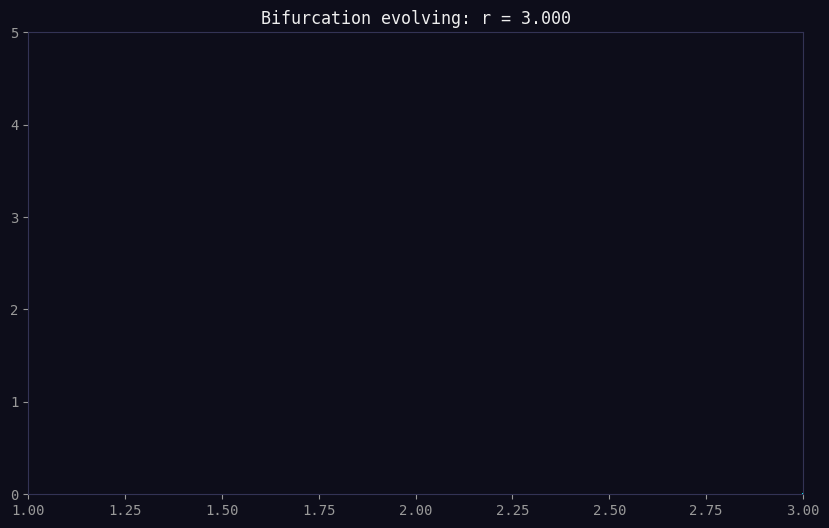

In [ ]:
import networkx as nx
from matplotlib.animation import FuncAnimation

def animate_network_cml():
    N = 40
    A = build_smallworld_adjacency(N)
    G = nx.from_numpy_array(A)

    pos = nx.spring_layout(G, seed=42)

    x = np.random.uniform(0.5, 3.0, N)

    fig, ax = plt.subplots(figsize=(8,8))

    def update(frame):
        nonlocal x
        ax.clear()

        x = cml_step(x, A, 2.7, 0.3)

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2)

        nodes = nx.draw_networkx_nodes(
            G, pos,
            node_color=x,
            cmap='plasma',
            node_size=100,
            ax=ax
        )

        ax.set_title(f"Network dynamics t={frame}")
        ax.axis('off')

        return nodes,

    anim = FuncAnimation(fig, update, frames=200, interval=50)
    anim.save("outputs/network_cml.mp4", fps=25)

animate_network_cml()

In [46]:
# Animation of the CML dynamics on different network topologies (ring, small-world, scale-free)

import networkx as nx
from matplotlib.animation import FuncAnimation
import os

os.makedirs("outputs", exist_ok=True)

def animate_network_cml_topology(adjacency_fn, name,
                                N=100, r=2.7, eps=0.3,
                                frames=250, fname="network.mp4"):

    A = adjacency_fn(N)
    G = nx.from_numpy_array(A)

    pos = nx.spring_layout(G, seed=42)
    x = np.random.uniform(0.5, 3.0, N)

    fig, ax = plt.subplots(figsize=(8,8))

    def update(frame):
        nonlocal x
        ax.clear()

        x = cml_step(x, A, r, eps)

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2)

        nodes = nx.draw_networkx_nodes(
            G, pos,
            node_color=x,
            cmap='plasma',
            node_size=120,
            ax=ax
        )

        ax.set_title(f"{name} | t={frame} | ε={eps}", fontsize=12)
        ax.axis('off')

        return nodes,

    anim = FuncAnimation(fig, update, frames=frames, interval=2)
    anim.save(f"outputs/{fname}", fps=6)
    plt.close()

In [47]:
# Ring
animate_network_cml_topology(
    build_ring_adjacency,
    name="Ring Lattice",
    fname="network_ring.mp4"
)

# Small-world
animate_network_cml_topology(
    lambda N: build_smallworld_adjacency(N, k=4, p=0.15),
    name="Small-World",
    fname="network_smallworld.mp4"
)

# Scale-free
animate_network_cml_topology(
    lambda N: build_scalefree_adjacency(N, m=2),
    name="Scale-Free",
    fname="network_scalefree.mp4"
)

In [39]:
# Lyapunov heatmap

def lyapunov_heatmap():
    r_vals = np.linspace(1, 3, 200)
    x0_vals = np.linspace(0.5, 3.0, 200)

    grid = np.zeros((len(r_vals), len(x0_vals)))

    for i, r in enumerate(r_vals):
        for j, x0 in enumerate(x0_vals):
            x = x0
            lya = 0
            for _ in range(500):
                deriv = abs(x * np.exp(r - x) * (2 - x))
                if deriv > 0:
                    lya += np.log(deriv)
                x = local_map(x, r)
            grid[i, j] = lya / 500

    plt.imshow(grid, aspect='auto', cmap='plasma',
               extent=[x0_vals[0], x0_vals[-1], r_vals[0], r_vals[-1]])
    plt.colorbar(label="Lyapunov exponent")
    plt.xlabel("Initial condition x0")
    plt.ylabel("r")
    plt.title("Lyapunov phase space")
    plt.savefig("outputs/lyapunov_heatmap.png", dpi=150)
    plt.close()

lyapunov_heatmap()

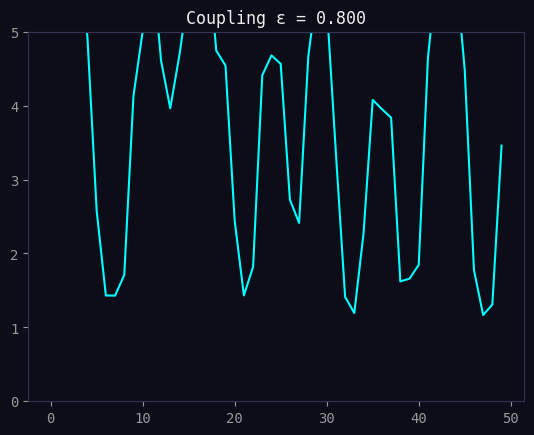

In [40]:
# Animation of the coupling transition

def animate_coupling_transition():
    N = 50
    A = build_ring_adjacency(N)
    x = np.random.uniform(0.5, 3.0, N)

    eps_values = np.linspace(0, 0.8, 150)

    fig, ax = plt.subplots()

    def update(frame):
        nonlocal x
        eps = eps_values[frame]

        x = cml_step(x, A, 2.7, eps)

        ax.clear()
        ax.plot(x, color='cyan')
        ax.set_ylim(0,5)
        ax.set_title(f"Coupling ε = {eps:.3f}")

    anim = FuncAnimation(fig, update, frames=len(eps_values))
    anim.save("outputs/coupling_transition.mp4", fps=30)

animate_coupling_transition()

In [41]:
# Detecting cluisters of synchronised nodes in the CML

def detect_clusters(x, tol=0.05):
    """
    Group nodes whose states are close (within tolerance).
    Returns list of clusters (lists of indices).
    """
    clusters = []
    used = set()

    for i in range(len(x)):
        if i in used:
            continue

        cluster = [i]
        used.add(i)

        for j in range(i+1, len(x)):
            if abs(x[i] - x[j]) < tol:
                cluster.append(j)
                used.add(j)

        clusters.append(cluster)

    return clusters

In [42]:
def get_cluster_colors(clusters, N):
    """
    Assign a unique color to each cluster.
    """
    colors = np.zeros(N)
    for idx, cluster in enumerate(clusters):
        for node in cluster:
            colors[node] = idx
    return colors

In [48]:
import networkx as nx
from matplotlib.animation import FuncAnimation

def animate_clusters():
    N = 40
    A = build_smallworld_adjacency(N)
    G = nx.from_numpy_array(A)
    pos = nx.spring_layout(G, seed=42)

    x = np.random.uniform(0.5, 3.0, N)

    fig, ax = plt.subplots(figsize=(8,8))

    def update(frame):
        nonlocal x
        ax.clear()

        x = cml_step(x, A, 2.7, 0.3)

        clusters = detect_clusters(x, tol=0.05)
        colors = get_cluster_colors(clusters, N)

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2)

        nodes = nx.draw_networkx_nodes(
            G, pos,
            node_color=colors,
            cmap='tab20',   # discrete colors
            node_size=120,
            ax=ax
        )

        ax.set_title(f"Clusters: {len(clusters)} groups | t={frame}")
        ax.axis('off')

        return nodes,

    anim = FuncAnimation(fig, update, frames=200, interval=5)
    anim.save("outputs/network_clusters.mp4", fps=6)
    plt.close()

animate_clusters()

In [44]:
# Cluster size evolution

def plot_cluster_evolution():
    N = 50
    A = build_ring_adjacency(N)
    x = np.random.uniform(0.5, 3.0, N)

    cluster_counts = []

    for t in range(300):
        x = cml_step(x, A, 2.7, 0.3)
        clusters = detect_clusters(x, tol=0.05)
        cluster_counts.append(len(clusters))

    plt.plot(cluster_counts, color='cyan')
    plt.xlabel("Time")
    plt.ylabel("Number of clusters")
    plt.title("Cluster evolution over time")
    plt.savefig("outputs/cluster_evolution.png", dpi=150)
    plt.close()

plot_cluster_evolution()